In [1]:
import os
os.environ["BACKEND_KERAS"]="tensorflow"
import keras
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt

2026-06-09 10:28:55.871142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781000936.038728      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781000936.086602      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781000936.466153      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781000936.466200      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781000936.466208      58 computation_placer.cc:177] computation placer alr

In [3]:
download_path= kagglehub.competition_download("dogs-vs-cats")

Mounting files to /kaggle/input/competitions/dogs-vs-cats...


In [4]:
import zipfile
with zipfile.ZipFile(download_path+"/train.zip","r") as zip_ref:
    zip_ref.extractall(".")


In [5]:
import shutil, pathlib
original_dir= pathlib.Path("train")
new_base_dir=pathlib.Path("dogs-vs-cats_small")
def make_subset(subset_name, start_index, end_index):
    for category in ("cat","dog"):
        dir = new_base_dir/subset_name/category
        os.makedirs(dir)
        fnames=[f"{category}.{i}.jpg" for i in range(start_index,end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir/fname, dst=dir/fname)
make_subset("train",start_index=0,end_index=1000)
make_subset("validation",start_index=1000,end_index=1500)
make_subset("test",start_index=1500,end_index=2500)

In [6]:
from keras.utils import image_dataset_from_directory
batch_size=64
image_size=(180,180)
train_dataset= image_dataset_from_directory(
    new_base_dir/"train",image_size=image_size,batch_size=batch_size
)
validation_dataset= image_dataset_from_directory(
    new_base_dir/"validation",image_size=image_size,batch_size=batch_size
)
test_dataset= image_dataset_from_directory(
    new_base_dir/"test",image_size=image_size,batch_size=batch_size
)

Found 2000 files belonging to 2 classes.


I0000 00:00:1781000984.264386      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [7]:
data_augmentation_layers=[
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]
def data_augmentation(images,targets):
    for layer in data_augmentation_layers:
        images= layer(images)
    return images, targets
augmented_train_dataset= train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset= augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

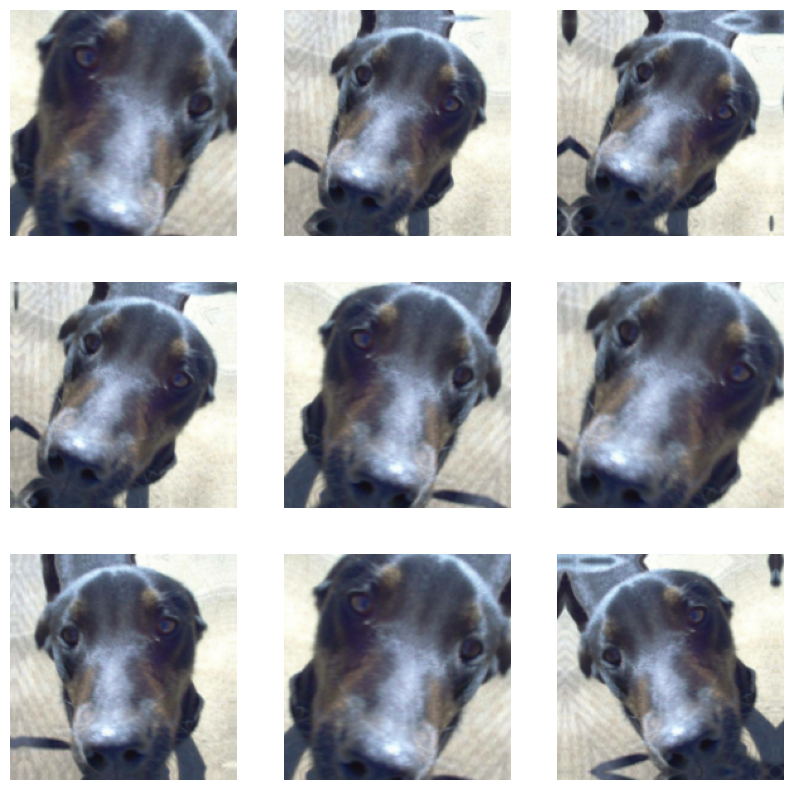

In [8]:
plt.figure(figsize=(10,10))
for image_batch,_ in train_dataset.take(1):
    image= image_batch[0]
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        augmented_image,_= data_augmentation(image,None)
        augmented_image= keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

In [9]:
inputs= keras.Input(shape=(180,180,3))
x= layers.Rescaling(1.0/255)(inputs)
x= layers.Conv2D(filters=32,kernel_size=5, use_bias=False)(x)

for size in [32,64,128,256,512]:
    residual= x
    
    x= layers.BatchNormalization()(x)
    x= layers.Activation("relu")(x)
    x= layers.SeparableConv2D(size,3,padding="same",use_bias=False)(x)
    
    x= layers.BatchNormalization()(x)
    x= layers.Activation("relu")(x)
    x= layers.SeparableConv2D(size,3,padding="same",use_bias=False)(x)

    x=layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual= layers.Conv2D(size,1,strides=2,padding="same",use_bias=False
                           )(residual)
    x=layers.add([x,residual])
x= layers.GlobalAveragePooling2D()(x)
x= layers.Dropout(0.5)(x)
outputs= layers.Dense(1,activation="sigmoid")(x)
model= keras.Model(inputs=inputs, outputs=outputs)
model.summary()

    

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 176, 176,  │      2,400 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 176, 176,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 176, 176,  │      1,312 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 176, 176,  │      1,312 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 88, 88,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 88, 88,    │      1,024 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 88, 88,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 88, 88,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 88, 88,    │      2,336 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 88, 88,    │          0 │ batch_normalizat

 Total params: 721,857 (2.75 MB)

 Trainable params: 718,849 (2.74 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [12]:
model.compile(
    loss="binary_crossentropy",
    optimizer= "adam",
    metrics=["accuracy"]
)
callbacks=[
    keras.callbacks.ModelCheckpoint(
        filepath="dogs_vs_cats_classifier_mini_xception.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [13]:
history= model.fit(
    augmented_train_dataset,
    epochs= 100,
    validation_data= validation_dataset,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1781001050.777377     112 service.cc:152] XLA service 0x3505e460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781001050.777430     112 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781001052.706132     112 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781001071.941899     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.5500 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.6105 - loss: 0.6515 - val_accuracy: 0.4940 - val_loss: 0.6931
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.6325 - loss: 0.6359 - val_accuracy: 0.5150 - val_loss: 0.6927
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - accuracy: 0.6350 - loss: 0.6261 - val_accuracy: 0.5330 - val_loss: 0.6922
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.6835 - loss: 0.5924 - val_accuracy: 0.4980 - val_loss: 0.6956
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.6920 - loss: 0.5862 - val_accuracy: 0.5000 - val_loss: 0.7091
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.6970 - loss: 0.5740 - val_accuracy: 0.5000 - val_loss: 0.7185
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step - accuracy: 0.7300 - loss: 0.5560 - val_accuracy: 0.5000 -

In [16]:
model= keras.models.load_model("dogs_vs_cats_classifier_mini_xception.keras")
test_loss, test_acc= model.evaluate(test_dataset)
print(f"test accuracy{test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.8735 - loss: 0.3630
test accuracy0.873


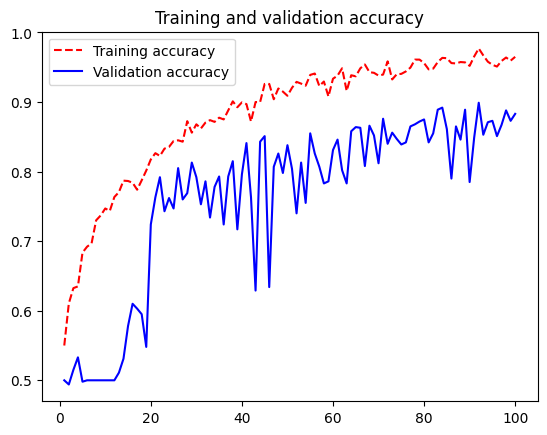

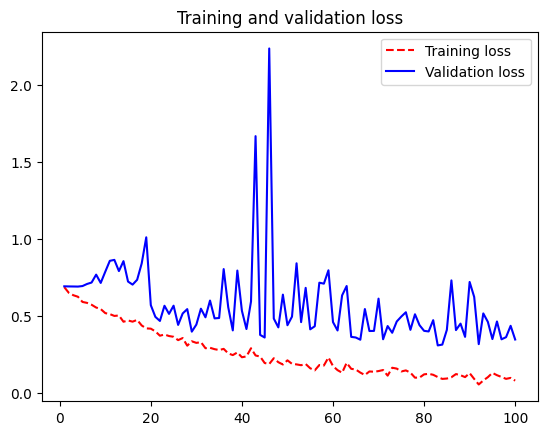

In [17]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()